In [19]:
from z3 import *
import numpy as np
import re
import arviz as az
import matplotlib.pyplot as plt
import os, sys
from importlib import reload

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(project_root)

import src.sat_metropolis.sat as sat
import src.sat_metropolis.smt as smt
import src.sat_metropolis.mcmc as mcmc
import src.sat_metropolis.utils as utils
# from sat_metropolis import smt, mcmc, sat, utils

reload(sat)
reload(smt)
reload(mcmc)
reload(utils)

<module 'src.sat_metropolis.utils' from '/Users/efh/Desktop/6. semester/Bachelor/sat-metropolis-businessnisser/src/sat_metropolis/utils.py'>

In [20]:
# Assumption, all bit-vectors are of the same size
## NOTE: It looks like we need to always have one extra bit? For the sign?
num_bits = 5
num_vars = 2
var_list = [BitVec(f'x{i}', num_bits) for i in range(num_vars)]
x = var_list
g = Goal()
sat.add_bool_vars_to_goal(g, var_list)
g.add(sat.addition_does_not_overflow([x[0], x[1]]))  # important
g.add(ULE(0, x[0]))
g.add(ULE(x[0], 10))
g.add(ULE(0, x[1]))
g.add(ULE(x[1], 10))

g.add(x[0] + x[1] == 11)

In [21]:
# trace = mcmc.sample_mh_trace_from_z3_model(backend='inc_pyunigen',
#                                            z3_problem=g,
#                                            num_vars=num_vars,
#                                            num_bits=num_bits,
#                                            num_samples=10,
#                                            num_iterations=100,
#                                            num_chains=4,
#                                            D=5)

In [22]:
trace = sat.get_conditional_incremental_samples_sat_pyunigen_problem_cached(
    z3_problem=g,
    num_vars=num_vars,
    num_bits=num_bits,
    D=10,
    num_samples=10,
    num_iterations=5000,
    sanity_check_problem=True,
    print_z3_model=False
)

variables_number: {1: k!130, 2: x00, 3: k!131, 4: x01, 5: k!132, 6: x02, 7: k!133, 8: x03, 9: k!134, 10: x04, 11: k!135, 12: x10, 13: k!136, 14: x11, 15: k!137, 16: x12, 17: k!138, 18: x13, 19: k!139, 20: x14, 21: k!140, 22: k!141, 23: k!142, 24: k!143, 25: k!144, 26: k!145, 27: k!146, 28: k!147, 29: k!148, 30: k!149, 31: k!150, 32: k!151, 33: k!152, 34: k!153, 35: k!154, 36: k!155, 37: k!156, 38: k!157, 39: k!158, 40: k!159, 41: k!160, 42: k!161, 43: k!162, 44: k!163, 45: k!164}
bit_map: {0: [2, 4, 6, 8, 10], 1: [12, 14, 16, 18, 20]}
Getting sample 0
Getting sample 1
Getting sample 2
Getting sample 3
Getting sample 4
Getting sample 5
Getting sample 6
Getting sample 7
Getting sample 8
Getting sample 9
Getting sample 10
Getting sample 11
Getting sample 12
Getting sample 13
Getting sample 14
Getting sample 15
Getting sample 16
Getting sample 17
Getting sample 18
Getting sample 19
Getting sample 20
Getting sample 21
Getting sample 22
Getting sample 23
Getting sample 24
Getting sample 25
G

In [23]:
trace

[{'x0': 7, 'x1': 4},
 {'x0': 10, 'x1': 1},
 {'x0': 2, 'x1': 9},
 {'x0': 7, 'x1': 4},
 {'x0': 1, 'x1': 10},
 {'x0': 2, 'x1': 9},
 {'x0': 5, 'x1': 6},
 {'x0': 7, 'x1': 4},
 {'x0': 5, 'x1': 6},
 {'x0': 6, 'x1': 5},
 {'x0': 5, 'x1': 6},
 {'x0': 2, 'x1': 9},
 {'x0': 9, 'x1': 2},
 {'x0': 7, 'x1': 4},
 {'x0': 4, 'x1': 7},
 {'x0': 1, 'x1': 10},
 {'x0': 1, 'x1': 10},
 {'x0': 1, 'x1': 10},
 {'x0': 4, 'x1': 7},
 {'x0': 7, 'x1': 4},
 {'x0': 8, 'x1': 3},
 {'x0': 8, 'x1': 3},
 {'x0': 1, 'x1': 10},
 {'x0': 7, 'x1': 4},
 {'x0': 3, 'x1': 8},
 {'x0': 2, 'x1': 9},
 {'x0': 9, 'x1': 2},
 {'x0': 3, 'x1': 8},
 {'x0': 7, 'x1': 4},
 {'x0': 1, 'x1': 10},
 {'x0': 8, 'x1': 3},
 {'x0': 9, 'x1': 2},
 {'x0': 2, 'x1': 9},
 {'x0': 7, 'x1': 4},
 {'x0': 5, 'x1': 6},
 {'x0': 2, 'x1': 9},
 {'x0': 6, 'x1': 5},
 {'x0': 1, 'x1': 10},
 {'x0': 10, 'x1': 1},
 {'x0': 7, 'x1': 4},
 {'x0': 8, 'x1': 3},
 {'x0': 1, 'x1': 10},
 {'x0': 8, 'x1': 3},
 {'x0': 7, 'x1': 4},
 {'x0': 7, 'x1': 4},
 {'x0': 9, 'x1': 2},
 {'x0': 8, 'x1': 3},
 {'

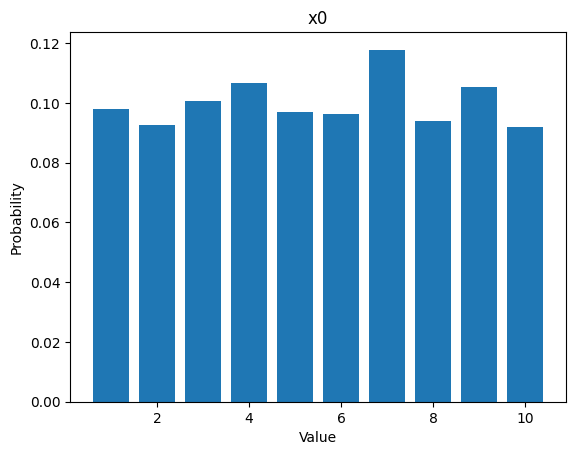

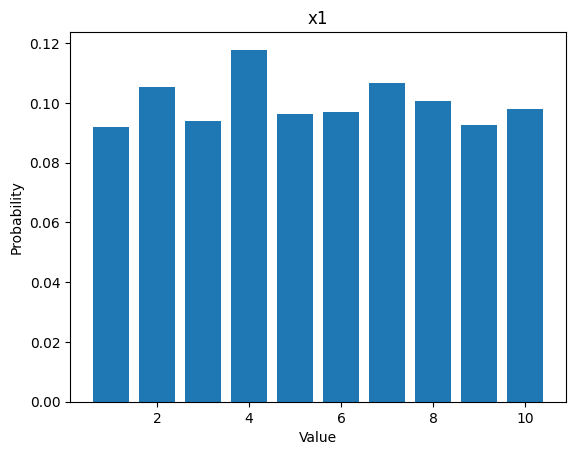

In [24]:
import matplotlib.pyplot as plt
from collections import Counter

for key in trace[0]:
    vals = [d[key] for d in trace]
    c = Counter(vals)

    total = sum(c.values())
    normalized = {k: v / total for k, v in c.items()}

    plt.figure()
    plt.bar(list(normalized.keys()), list(normalized.values()))
    plt.title(key)
    plt.ylabel("Probability")
    plt.xlabel("Value")
    plt.show()

In [25]:
# Trace plot
az.plot_trace(trace);
plt.savefig('unigen_triangle_trace_plot.png',dpi=150);

ValueError: Can only convert xarray dataarray, xarray dataset, dict, pytree (if 'dm-tree' is installed), netcdf filename, numpy array, object with __array__, pystan fit, emcee fit, pyro mcmc fit, numpyro mcmc fit, cmdstan fit csv filename, cmdstanpy fit to InferenceData, not list

In [ ]:
# Diagnosis
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,1.705,1.125,0.0,3.0,0.003,0.001,119979.0,119994.0,1.0
x1,1.707,1.124,0.0,3.0,0.003,0.001,118689.0,117450.0,1.0
x2,3.412,1.670,1.0,6.0,0.005,0.003,120501.0,120000.0,1.0


In [ ]:
utils.save_trace(trace, f'triangle_SAT_unigen_{num_vars}_{num_bits}.nc')

## Non-uniform prior

In [ ]:
def prior(s: dict[str, int]):
    x0 = s['x0']
    x1 = s['x1']
    p_x0 = 1/3 if x0 < 2 else 1/6
    p_x1 = 1/4

    return p_x0 * p_x1

def likelihood(s: dict[str, int]):
    return 1

In [ ]:
trace = mcmc.sample_mh_trace_from_z3_model(backend='unigen',
                                           z3_problem=g,
                                           num_vars=num_vars,
                                           num_bits=num_bits,
                                           num_samples=30000,
                                           num_chains=4,
                                           f= lambda s: prior(s)*likelihood(s))

c CMSGen Copyright Mate Soos (soos.mate@gmail.com)
c CMSGen SHA revision 422a9dbaba3f749c2df811d9dfab7ffd4627bac5
c CMSGen is MIT licensed
c CMSGen compilation env CMAKE_CXX_COMPILER = /usr/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 -Wno-class-memaccess -Wlogical-op -Wrestrict -Wnull-dereference -Wdouble-promotion -Wshadow -Wformat=2 -Wextra-semi -pedantic | COMPILE_DEFINES =  -DUSE_GAUSS -DUSE_ZLIB -DYALSAT_FPU | STATICCOMPILE = OFF | ZLIB_FOUND = TRUE | VALGRIND_FOUND =  | ENABLE_TESTING =  | SLOW_DEBUG = OFF | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | LARGEMEM =  | LIMITMEM =  | 
c CMSGen compiled with gcc version 13.2.0
c executed with command line: cmsgen --samples 30000 --samplefile cmsgen_input/cmsgen_samples.out cmsgen_input/z3_problem.cnf
c Writing sam

### Posterior analysis

We observe the in the traceplot below the effect of the prior on $x_0$. Now it is distributed as according to the categorical distribution above. As opposed to the uniform prior we used in the previous analysis.

The distribution of $x_2$ is also affected by the new prior on $x_0$.

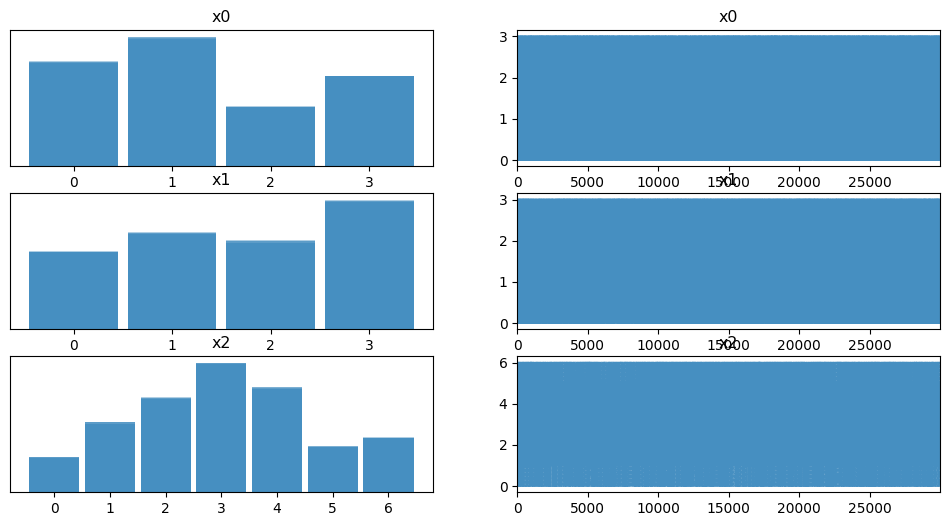

In [ ]:
az.plot_trace(trace);
plt.savefig('unigen_trace_plot_non_uniform.png',dpi=150);

In [ ]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,1.354,1.117,0.0,3.0,0.004,0.002,67702.0,64904.0,1.0
x1,1.686,1.127,0.0,3.0,0.004,0.002,80412.0,79281.0,1.0
x2,3.040,1.658,0.0,6.0,0.006,0.003,72876.0,65125.0,1.0


In [ ]:
utils.save_trace(trace, f'triangle_prior_SAT_unigen_{num_vars}_{num_bits}.nc')